In [1]:
# 1. Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, KFold

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (200, 13)

First 5 Rows:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    str    
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-nul

In [3]:
# 3. Basic Data Cleaning
# ============================================================

# Fill missing numeric values with mean
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64


In [25]:
# 4. Correct Binning Function
# IMPORTANT: This prevents duplicate names
# ============================================================

def percentile_bin(series):
    """
    Converts continuous values into Low, Medium, High categories.
    Only returns Low/Medium/High to avoid duplicate dummy names.
    """
    return pd.qcut(
        series,
        q=3,
        labels=["Low", "Medium", "High"],
        duplicates="drop"
    )


# ============================================================
# 5. Create Categorical Pollution and Energy Features
# ============================================================

df['Air_Pollution_Severity'] = percentile_bin(
    df['Air_Pollution_Index']
)

df['Water_Pollution_Severity'] = percentile_bin(
    df['Water_Pollution_Index']
)

df['Soil_Pollution_Severity'] = percentile_bin(
    df['Soil_Pollution_Index']
)

df['Industrial_Waste_Level'] = percentile_bin(
    df['Industrial_Waste (in tons)']
)

df['CO2_Emission_Level'] = percentile_bin(
    df['CO2_Emissions (in MT)']
)

df['Energy_Consumption_Level'] = percentile_bin(
    df['Energy_Consumption_Per_Capita (in MWh)']
)

df['Energy_Recovery_Level'] = percentile_bin(
    df['Energy_Recovered (in GWh)']
)

df['Renewable_Energy_Level'] = percentile_bin(
    df['Renewable_Energy (%)']
)

category_cols = [
    'Air_Pollution_Severity',
    'Water_Pollution_Severity',
    'Soil_Pollution_Severity',
    'Industrial_Waste_Level',
    'CO2_Emission_Level',
    'Energy_Consumption_Level',
    'Energy_Recovery_Level',
    'Renewable_Energy_Level'
]

display(df[category_cols].head())

,Air_Pollution_Severity,Water_Pollution_Severity,Soil_Pollution_Severity,Industrial_Waste_Level,CO2_Emission_Level,Energy_Consumption_Level,Energy_Recovery_Level,Renewable_Energy_Level
0,High,Medium,Low,High,Low,High,Low,High
1,Low,Low,High,Medium,Low,Low,High,High
2,Low,Low,High,Medium,High,High,High,Low
3,High,Low,Medium,High,Low,Low,Low,Low
4,Medium,Medium,High,High,Low,High,Low,Medium


In [26]:
# ============================================================
# 6. Create Transaction Dataset
# ============================================================

transaction_df = df[category_cols].copy()

print("Transaction Dataset:")
display(transaction_df.head())

Transaction Dataset:


,Air_Pollution_Severity,Water_Pollution_Severity,Soil_Pollution_Severity,Industrial_Waste_Level,CO2_Emission_Level,Energy_Consumption_Level,Energy_Recovery_Level,Renewable_Energy_Level
0,High,Medium,Low,High,Low,High,Low,High
1,Low,Low,High,Medium,Low,Low,High,High
2,Low,Low,High,Medium,High,High,High,Low
3,High,Low,Medium,High,Low,Low,Low,Low
4,Medium,Medium,High,High,Low,High,Low,Medium


In [27]:
# ============================================================
# 7. One-Hot Encoding
# ============================================================

encoded_df = pd.get_dummies(transaction_df).astype(bool)

print("Encoded Dataset Shape:", encoded_df.shape)
display(encoded_df.head())

print("\nEncoded Columns:")
print(encoded_df.columns.tolist())

Encoded Dataset Shape: (200, 24)


,Air_Pollution_Severity_Low,Air_Pollution_Severity_Medium,Air_Pollution_Severity_High,Water_Pollution_Severity_Low,Water_Pollution_Severity_Medium,Water_Pollution_Severity_High,Soil_Pollution_Severity_Low,Soil_Pollution_Severity_Medium,Soil_Pollution_Severity_High,Industrial_Waste_Level_Low,...,CO2_Emission_Level_High,Energy_Consumption_Level_Low,Energy_Consumption_Level_Medium,Energy_Consumption_Level_High,Energy_Recovery_Level_Low,Energy_Recovery_Level_Medium,Energy_Recovery_Level_High,Renewable_Energy_Level_Low,Renewable_Energy_Level_Medium,Renewable_Energy_Level_High
0,False,False,True,False,True,False,True,False,False,False,...,False,False,False,True,True,False,False,False,False,True
1,True,False,False,True,False,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,True
2,True,False,False,True,False,False,False,False,True,False,...,True,False,False,True,False,False,True,True,False,False
3,False,False,True,True,False,False,False,True,False,False,...,False,True,False,False,True,False,False,True,False,False
4,False,True,False,False,True,False,False,False,True,False,...,False,False,False,True,True,False,False,False,True,False



Encoded Columns:
['Air_Pollution_Severity_Low', 'Air_Pollution_Severity_Medium', 'Air_Pollution_Severity_High', 'Water_Pollution_Severity_Low', 'Water_Pollution_Severity_Medium', 'Water_Pollution_Severity_High', 'Soil_Pollution_Severity_Low', 'Soil_Pollution_Severity_Medium', 'Soil_Pollution_Severity_High', 'Industrial_Waste_Level_Low', 'Industrial_Waste_Level_Medium', 'Industrial_Waste_Level_High', 'CO2_Emission_Level_Low', 'CO2_Emission_Level_Medium', 'CO2_Emission_Level_High', 'Energy_Consumption_Level_Low', 'Energy_Consumption_Level_Medium', 'Energy_Consumption_Level_High', 'Energy_Recovery_Level_Low', 'Energy_Recovery_Level_Medium', 'Energy_Recovery_Level_High', 'Renewable_Energy_Level_Low', 'Renewable_Energy_Level_Medium', 'Renewable_Energy_Level_High']


In [28]:
# 8. Apriori Frequent Itemsets
# ============================================================

MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.60

frequent_itemsets = apriori(
    encoded_df,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by='support',
    ascending=False
).reset_index(drop=True)

print("Total Frequent Itemsets:", len(frequent_itemsets))
display(frequent_itemsets.head(20))

Total Frequent Itemsets: 566


,support,itemsets
0,0.335,frozenset({Renewable_Energy_Level_High})
1,0.335,frozenset({Energy_Consumption_Level_High})
2,0.335,frozenset({Energy_Recovery_Level_Low})
3,0.335,frozenset({Energy_Recovery_Level_High})
4,0.335,frozenset({Renewable_Energy_Level_Low})
5,0.335,frozenset({Soil_Pollution_Severity_High})
6,0.335,frozenset({Energy_Consumption_Level_Low})
7,0.335,frozenset({CO2_Emission_Level_Low})
8,0.335,frozenset({CO2_Emission_Level_High})
9,0.335,frozenset({Water_Pollution_Severity_High})


In [29]:
# 9. Association Rules
# ============================================================

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

rules = rules[rules['lift'] > 1.0]

rules = rules.sort_values(
    by='lift',
    ascending=False
).reset_index(drop=True)

print(f"Total rules confidence >= {MIN_CONFIDENCE}, lift > 1.0: {len(rules)}")

display(
    rules[
        ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    ].round(4)
)

Total rules confidence >= 0.6, lift > 1.0: 34


,antecedents,consequents,support,confidence,lift
0,"frozenset({Renewable_Energy_Level_Medium, Indu...",frozenset({Soil_Pollution_Severity_Low}),0.050,0.9091,2.7137
1,"frozenset({Soil_Pollution_Severity_Low, Indust...",frozenset({Renewable_Energy_Level_Medium}),0.050,0.7692,2.3310
2,"frozenset({Soil_Pollution_Severity_Low, Renewa...",frozenset({Air_Pollution_Severity_High}),0.050,0.7692,2.2962
3,"frozenset({Energy_Recovery_Level_High, Water_P...",frozenset({CO2_Emission_Level_Low}),0.055,0.6875,2.0522
4,"frozenset({Water_Pollution_Severity_Medium, In...",frozenset({CO2_Emission_Level_Low}),0.070,0.6667,1.9900
5,"frozenset({Water_Pollution_Severity_High, Soil...",frozenset({Air_Pollution_Severity_Low}),0.080,0.6667,1.9900
6,"frozenset({Soil_Pollution_Severity_Low, Renewa...",frozenset({Industrial_Waste_Level_Low}),0.050,0.6667,1.9900
7,"frozenset({Renewable_Energy_Level_High, Air_Po...",frozenset({Industrial_Waste_Level_Low}),0.060,0.6667,1.9900
8,"frozenset({Air_Pollution_Severity_Medium, CO2_...",frozenset({Water_Pollution_Severity_Medium}),0.075,0.6522,1.9763
9,"frozenset({Energy_Recovery_Level_High, Air_Pol...",frozenset({Renewable_Energy_Level_High}),0.075,0.6522,1.9468


In [30]:
# 10. Clean Rule Display Function
# ============================================================

def itemset_to_string(itemset):
    return ', '.join(list(itemset))

rules_display = rules.copy()

rules_display['antecedents'] = rules_display['antecedents'].apply(itemset_to_string)
rules_display['consequents'] = rules_display['consequents'].apply(itemset_to_string)

display(
    rules_display[
        ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    ].round(4)
)

,antecedents,consequents,support,confidence,lift
0,"Renewable_Energy_Level_Medium, Industrial_Wast...",Soil_Pollution_Severity_Low,0.050,0.9091,2.7137
1,"Soil_Pollution_Severity_Low, Industrial_Waste_...",Renewable_Energy_Level_Medium,0.050,0.7692,2.3310
2,"Soil_Pollution_Severity_Low, Renewable_Energy_...",Air_Pollution_Severity_High,0.050,0.7692,2.2962
3,"Energy_Recovery_Level_High, Water_Pollution_Se...",CO2_Emission_Level_Low,0.055,0.6875,2.0522
4,"Water_Pollution_Severity_Medium, Industrial_Wa...",CO2_Emission_Level_Low,0.070,0.6667,1.9900
5,"Water_Pollution_Severity_High, Soil_Pollution_...",Air_Pollution_Severity_Low,0.080,0.6667,1.9900
6,"Soil_Pollution_Severity_Low, Renewable_Energy_...",Industrial_Waste_Level_Low,0.050,0.6667,1.9900
7,"Renewable_Energy_Level_High, Air_Pollution_Sev...",Industrial_Waste_Level_Low,0.060,0.6667,1.9900
8,"Air_Pollution_Severity_Medium, CO2_Emission_Le...",Water_Pollution_Severity_Medium,0.075,0.6522,1.9763
9,"Energy_Recovery_Level_High, Air_Pollution_Seve...",Renewable_Energy_Level_High,0.075,0.6522,1.9468


In [31]:
# 11. Correct Chi-Square Test for Multi-Item Rules
# ============================================================

chi2_results = []

for _, rule in rules.iterrows():

    ants = list(rule['antecedents'])
    cons = list(rule['consequents'])

    ant_true = encoded_df[ants].all(axis=1)
    con_true = encoded_df[cons].all(axis=1)

    n11 = (ant_true & con_true).sum()
    n10 = (ant_true & ~con_true).sum()
    n01 = (~ant_true & con_true).sum()
    n00 = (~ant_true & ~con_true).sum()

    contingency = [[n11, n10], [n01, n00]]

    chi2, p, dof, expected = chi2_contingency(contingency)

    chi2_results.append({
        'antecedents': rule['antecedents'],
        'consequents': rule['consequents'],
        'support': rule['support'],
        'confidence': rule['confidence'],
        'lift': rule['lift'],
        'chi2': round(chi2, 4),
        'p_value': round(p, 4),
        'significant': p < 0.05
    })

chi2_df = pd.DataFrame(chi2_results)

sig_rules = chi2_df[
    (chi2_df['confidence'] >= MIN_CONFIDENCE) &
    (chi2_df['lift'] > 1.0) &
    (chi2_df['p_value'] < 0.05)
].sort_values(by='lift', ascending=False).reset_index(drop=True)

print("Strong statistically significant rules:", len(sig_rules))

display(
    sig_rules[
        ['antecedents', 'consequents',
         'support', 'confidence', 'lift', 'p_value']
    ].round(4)
)

Strong statistically significant rules: 34


,antecedents,consequents,support,confidence,lift,p_value
0,"frozenset({Renewable_Energy_Level_Medium, Indu...",frozenset({Soil_Pollution_Severity_Low}),0.050,0.9091,2.7137,0.0001
1,"frozenset({Soil_Pollution_Severity_Low, Indust...",frozenset({Renewable_Energy_Level_Medium}),0.050,0.7692,2.3310,0.0015
2,"frozenset({Soil_Pollution_Severity_Low, Renewa...",frozenset({Air_Pollution_Severity_High}),0.050,0.7692,2.2962,0.0018
3,"frozenset({Energy_Recovery_Level_High, Water_P...",frozenset({CO2_Emission_Level_Low}),0.055,0.6875,2.0522,0.0045
4,"frozenset({Water_Pollution_Severity_Medium, In...",frozenset({CO2_Emission_Level_Low}),0.070,0.6667,1.9900,0.0016
5,"frozenset({Water_Pollution_Severity_High, Soil...",frozenset({Air_Pollution_Severity_Low}),0.080,0.6667,1.9900,0.0006
6,"frozenset({Soil_Pollution_Severity_Low, Renewa...",frozenset({Industrial_Waste_Level_Low}),0.050,0.6667,1.9900,0.0109
7,"frozenset({Renewable_Energy_Level_High, Air_Po...",frozenset({Industrial_Waste_Level_Low}),0.060,0.6667,1.9900,0.0042
8,"frozenset({Air_Pollution_Severity_Medium, CO2_...",frozenset({Water_Pollution_Severity_Medium}),0.075,0.6522,1.9763,0.0011
9,"frozenset({Energy_Recovery_Level_High, Air_Pol...",frozenset({Renewable_Energy_Level_High}),0.075,0.6522,1.9468,0.0014


In [32]:
# 12. Strong Rules
# ============================================================

strong_rules = sig_rules.copy()

print("Strong significant rules:", len(strong_rules))

strong_rules_display = strong_rules.copy()

strong_rules_display['antecedents'] = strong_rules_display['antecedents'].apply(itemset_to_string)
strong_rules_display['consequents'] = strong_rules_display['consequents'].apply(itemset_to_string)

display(
    strong_rules_display[
        ['antecedents', 'consequents',
         'support', 'confidence', 'lift', 'p_value']
    ].round(4)
)

Strong significant rules: 34


,antecedents,consequents,support,confidence,lift,p_value
0,"Renewable_Energy_Level_Medium, Industrial_Wast...",Soil_Pollution_Severity_Low,0.050,0.9091,2.7137,0.0001
1,"Soil_Pollution_Severity_Low, Industrial_Waste_...",Renewable_Energy_Level_Medium,0.050,0.7692,2.3310,0.0015
2,"Soil_Pollution_Severity_Low, Renewable_Energy_...",Air_Pollution_Severity_High,0.050,0.7692,2.2962,0.0018
3,"Energy_Recovery_Level_High, Water_Pollution_Se...",CO2_Emission_Level_Low,0.055,0.6875,2.0522,0.0045
4,"Water_Pollution_Severity_Medium, Industrial_Wa...",CO2_Emission_Level_Low,0.070,0.6667,1.9900,0.0016
5,"Water_Pollution_Severity_High, Soil_Pollution_...",Air_Pollution_Severity_Low,0.080,0.6667,1.9900,0.0006
6,"Soil_Pollution_Severity_Low, Renewable_Energy_...",Industrial_Waste_Level_Low,0.050,0.6667,1.9900,0.0109
7,"Renewable_Energy_Level_High, Air_Pollution_Sev...",Industrial_Waste_Level_Low,0.060,0.6667,1.9900,0.0042
8,"Air_Pollution_Severity_Medium, CO2_Emission_Le...",Water_Pollution_Severity_Medium,0.075,0.6522,1.9763,0.0011
9,"Energy_Recovery_Level_High, Air_Pollution_Seve...",Renewable_Energy_Level_High,0.075,0.6522,1.9468,0.0014


In [33]:
# 13. Rule Interpretation for Top Strong Rules
# ============================================================

def clean_item(item):
    """
    Convert item names into readable text.
    Example:
    Energy_Recovery_Level_High -> High Energy Recovery Level
    """
    parts = item.split('_')
    level = parts[-1]
    feature = ' '.join(parts[:-1])
    return f"{level} {feature}"


def interpret_rule(row):
    antecedents = list(row['antecedents'])
    consequents = list(row['consequents'])

    antecedent_text = " and ".join([clean_item(item) for item in antecedents])
    consequent_text = " and ".join([clean_item(item) for item in consequents])

    support = row['support']
    confidence = row['confidence']
    lift = row['lift']
    p_value = row['p_value']

    if confidence >= 0.70:
        strength = "strong"
    elif confidence >= 0.60:
        strength = "moderately strong"
    else:
        strength = "moderate"

    if lift >= 2:
        lift_meaning = "very strong positive association"
    elif lift >= 1.5:
        lift_meaning = "strong positive association"
    elif lift > 1:
        lift_meaning = "positive association"
    else:
        lift_meaning = "weak association"

    text = f"""
Rule:
{set(antecedents)} → {set(consequents)}

Support: {support:.3f}
Confidence: {confidence:.3f}
Lift: {lift:.3f}
p-value: {p_value:.4f}

Interpretation:
This rule shows that when {antecedent_text} occurs, {consequent_text} also tends to occur.
The support value of {support:.3f} means this pattern appears in {support * 100:.1f}% of the dataset.
The confidence value of {confidence:.3f} means that in {confidence * 100:.1f}% of cases where {antecedent_text} is present, {consequent_text} is also present.
The lift value of {lift:.3f} indicates a {lift_meaning} compared to random chance.
Since the p-value is {p_value:.4f}, this rule is statistically significant.
Overall, this is a {strength} association.
"""
    return text


top_rules = strong_rules.sort_values(by='lift', ascending=False).head(5)

for i, (_, row) in enumerate(top_rules.iterrows(), start=1):
    print("=" * 90)
    print(f"Interpretation for Rule {i}")
    print("=" * 90)
    print(interpret_rule(row))

Interpretation for Rule 1

Rule:
{'Renewable_Energy_Level_Medium', 'Industrial_Waste_Level_Low', 'Air_Pollution_Severity_High'} → {'Soil_Pollution_Severity_Low'}

Support: 0.050
Confidence: 0.909
Lift: 2.714
p-value: 0.0001

Interpretation:
This rule shows that when Medium Renewable Energy Level and Low Industrial Waste Level and High Air Pollution Severity occurs, Low Soil Pollution Severity also tends to occur.
The support value of 0.050 means this pattern appears in 5.0% of the dataset.
The confidence value of 0.909 means that in 90.9% of cases where Medium Renewable Energy Level and Low Industrial Waste Level and High Air Pollution Severity is present, Low Soil Pollution Severity is also present.
The lift value of 2.714 indicates a very strong positive association compared to random chance.
Since the p-value is 0.0001, this rule is statistically significant.
Overall, this is a strong association.

Interpretation for Rule 2

Rule:
{'Soil_Pollution_Severity_Low', 'Industrial_Waste_Le

In [34]:
# ============================================================
# 14. FP-Growth Algorithm Comparison
# ============================================================

fp_itemsets = fpgrowth(
    encoded_df,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

fp_rules = association_rules(
    fp_itemsets,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

fp_rules = fp_rules[fp_rules['lift'] > 1.0]

fp_rules = fp_rules.sort_values(
    by='lift',
    ascending=False
).reset_index(drop=True)

print("========== Algorithm Comparison ==========")
print(f"{'Metric':<25} {'Apriori':>10} {'FP-Growth':>10}")
print("-" * 50)

print(f"{'Total Rules':<25} {len(rules):>10} {len(fp_rules):>10}")
print(f"{'Avg Support':<25} {rules['support'].mean():>10.3f} {fp_rules['support'].mean():>10.3f}")
print(f"{'Avg Confidence':<25} {rules['confidence'].mean():>10.3f} {fp_rules['confidence'].mean():>10.3f}")
print(f"{'Avg Lift':<25} {rules['lift'].mean():>10.3f} {fp_rules['lift'].mean():>10.3f}")
print(f"{'Max Lift':<25} {rules['lift'].max():>10.3f} {fp_rules['lift'].max():>10.3f}")

print("\nVerdict:")
if len(rules) == len(fp_rules):
    print("Both algorithms produced the same number of rules.")
    print("The discovered associations are consistent across algorithms.")
else:
    print("Apriori and FP-Growth produced different numbers of rules.")

========== Algorithm Comparison ==========
Metric                       Apriori  FP-Growth
--------------------------------------------------
Total Rules                       34         34
Avg Support                    0.065      0.065
Avg Confidence                 0.645      0.645
Avg Lift                       1.936      1.936
Max Lift                       2.714      2.714

Verdict:
Both algorithms produced the same number of rules.
The discovered associations are consistent across algorithms.


In [35]:
# ============================================================
# 15. Train-Test Validation
# ============================================================

train_df, test_df = train_test_split(
    encoded_df,
    test_size=0.2,
    random_state=42
)

train_itemsets = apriori(
    train_df,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

train_rules = association_rules(
    train_itemsets,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

train_rules = train_rules[train_rules['lift'] > 1.0]


test_itemsets = apriori(
    test_df,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

test_rules = association_rules(
    test_itemsets,
    metric='confidence',
    min_threshold=MIN_CONFIDENCE
)

test_rules = test_rules[test_rules['lift'] > 1.0]


print("========== Train-Test Validation ==========")
print("Train Rules:", len(train_rules))
print("Test Rules:", len(test_rules))

if len(train_rules) > 0:
    print("\nTrain Average Support:", round(train_rules['support'].mean(), 4))
    print("Train Average Confidence:", round(train_rules['confidence'].mean(), 4))
    print("Train Average Lift:", round(train_rules['lift'].mean(), 4))

if len(test_rules) > 0:
    print("\nTest Average Support:", round(test_rules['support'].mean(), 4))
    print("Test Average Confidence:", round(test_rules['confidence'].mean(), 4))
    print("Test Average Lift:", round(test_rules['lift'].mean(), 4))

========== Train-Test Validation ==========
Train Rules: 91
Test Rules: 4509

Train Average Support: 0.0624
Train Average Confidence: 0.6588
Train Average Lift: 1.9358

Test Average Support: 0.0558
Test Average Confidence: 0.8254
Test Average Lift: 4.0492


In [36]:
# ============================================================
# 16. K-Fold Cross Validation
# ============================================================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

for fold, (train_index, test_index) in enumerate(kf.split(encoded_df), start=1):

    train_fold = encoded_df.iloc[train_index]

    fold_itemsets = apriori(
        train_fold,
        min_support=MIN_SUPPORT,
        use_colnames=True
    )

    if fold_itemsets.empty:
        fold_results.append({
            'Fold': fold,
            'Rules': 0,
            'Avg Support': 0,
            'Avg Confidence': 0,
            'Avg Lift': 0
        })
        continue

    fold_rules = association_rules(
        fold_itemsets,
        metric='confidence',
        min_threshold=MIN_CONFIDENCE
    )

    fold_rules = fold_rules[fold_rules['lift'] > 1.0]

    if fold_rules.empty:
        fold_results.append({
            'Fold': fold,
            'Rules': 0,
            'Avg Support': 0,
            'Avg Confidence': 0,
            'Avg Lift': 0
        })
    else:
        fold_results.append({
            'Fold': fold,
            'Rules': len(fold_rules),
            'Avg Support': round(fold_rules['support'].mean(), 4),
            'Avg Confidence': round(fold_rules['confidence'].mean(), 4),
            'Avg Lift': round(fold_rules['lift'].mean(), 4)
        })

fold_df = pd.DataFrame(fold_results)

print("========== K-Fold Cross Validation Results ==========")
display(fold_df)

print("\nAverage Across Folds:")
display(fold_df.mean(numeric_only=True))

========== K-Fold Cross Validation Results ==========


,Fold,Rules,Avg Support,Avg Confidence,Avg Lift
0,1,91,0.0624,0.6588,1.9358
1,2,53,0.0616,0.6648,1.9800
2,3,78,0.0643,0.6632,1.9620
3,4,76,0.0660,0.6446,1.8960
4,5,48,0.0633,0.6527,1.9495



Average Across Folds:


Fold               3.00000
Rules             69.20000
Avg Support        0.06352
Avg Confidence     0.65682
Avg Lift           1.94466
dtype: float64

In [37]:
# ============================================================
# 17. Sensitivity Analysis
# ============================================================

support_values = [0.03, 0.04, 0.05, 0.06, 0.07, 0.10]
confidence_values = [0.45, 0.50, 0.60, 0.70]

sensitivity_results = []

for support in support_values:

    temp_itemsets = apriori(
        encoded_df,
        min_support=support,
        use_colnames=True
    )

    for confidence in confidence_values:

        if temp_itemsets.empty:
            total_rules = 0
            avg_support = 0
            avg_confidence = 0
            avg_lift = 0
            max_lift = 0

        else:
            temp_rules = association_rules(
                temp_itemsets,
                metric='confidence',
                min_threshold=confidence
            )

            temp_rules = temp_rules[temp_rules['lift'] > 1.0]

            total_rules = len(temp_rules)

            if total_rules > 0:
                avg_support = temp_rules['support'].mean()
                avg_confidence = temp_rules['confidence'].mean()
                avg_lift = temp_rules['lift'].mean()
                max_lift = temp_rules['lift'].max()
            else:
                avg_support = 0
                avg_confidence = 0
                avg_lift = 0
                max_lift = 0

        sensitivity_results.append({
            'min_support': support,
            'min_confidence': confidence,
            'total_rules': total_rules,
            'avg_support': round(avg_support, 4),
            'avg_confidence': round(avg_confidence, 4),
            'avg_lift': round(avg_lift, 4),
            'max_lift': round(max_lift, 4)
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

print("========== Sensitivity Analysis ==========")
display(sensitivity_df)

========== Sensitivity Analysis ==========


,min_support,min_confidence,total_rules,avg_support,avg_confidence,avg_lift,max_lift
0,0.03,0.45,1353,0.0418,0.5779,1.7488,5.0000
1,0.03,0.50,1042,0.0393,0.6107,1.8430,5.0000
2,0.03,0.60,515,0.0345,0.6928,2.0851,5.0000
3,0.03,0.70,197,0.0335,0.7891,2.3685,3.0303
4,0.04,0.45,606,0.0546,0.5256,1.5807,3.2841
5,0.04,0.50,356,0.0545,0.5650,1.6958,3.0303
6,0.04,0.60,84,0.0504,0.6848,2.0569,3.0303
7,0.04,0.70,26,0.0412,0.8044,2.4176,3.0303
8,0.05,0.45,461,0.0588,0.5098,1.5342,3.2841
9,0.05,0.50,252,0.0602,0.5439,1.6317,2.7137


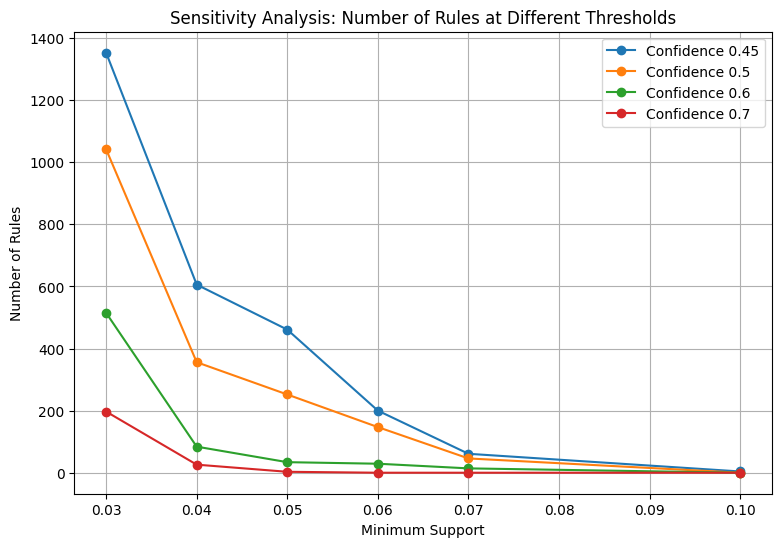

In [38]:
# 18. Sensitivity Analysis Visualization
# ============================================================

plt.figure(figsize=(9, 6))

for confidence in confidence_values:
    subset = sensitivity_df[sensitivity_df['min_confidence'] == confidence]

    plt.plot(
        subset['min_support'],
        subset['total_rules'],
        marker='o',
        label=f'Confidence {confidence}'
    )

plt.xlabel('Minimum Support')
plt.ylabel('Number of Rules')
plt.title('Sensitivity Analysis: Number of Rules at Different Thresholds')
plt.legend()
plt.grid(True)
plt.show()

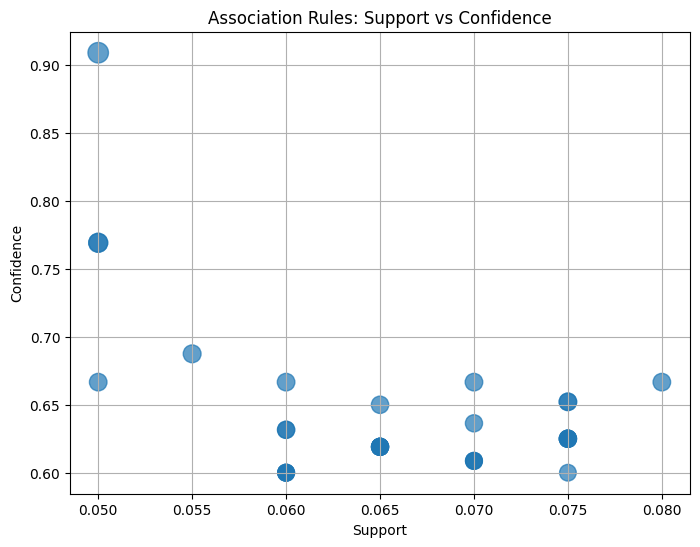

In [39]:
# 19. Support vs Confidence Visualization
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    rules['support'],
    rules['confidence'],
    s=rules['lift'] * 80,
    alpha=0.7
)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence')
plt.grid(True)
plt.show()

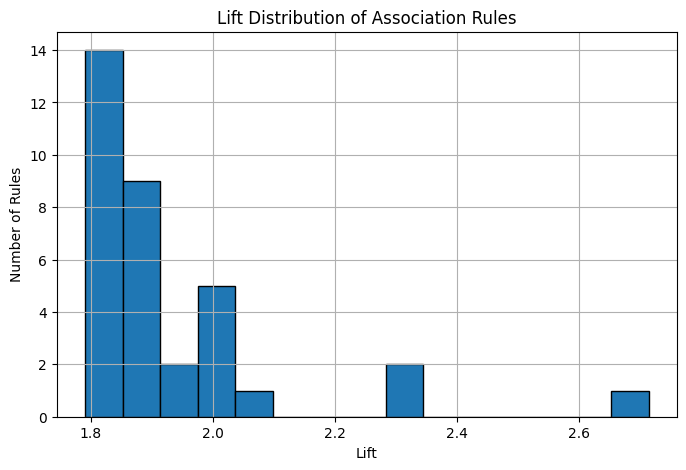

In [40]:
# 20. Lift Distribution Visualization
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    rules['lift'],
    bins=15,
    edgecolor='black'
)

plt.xlabel('Lift')
plt.ylabel('Number of Rules')
plt.title('Lift Distribution of Association Rules')S
plt.grid(True)
plt.show()

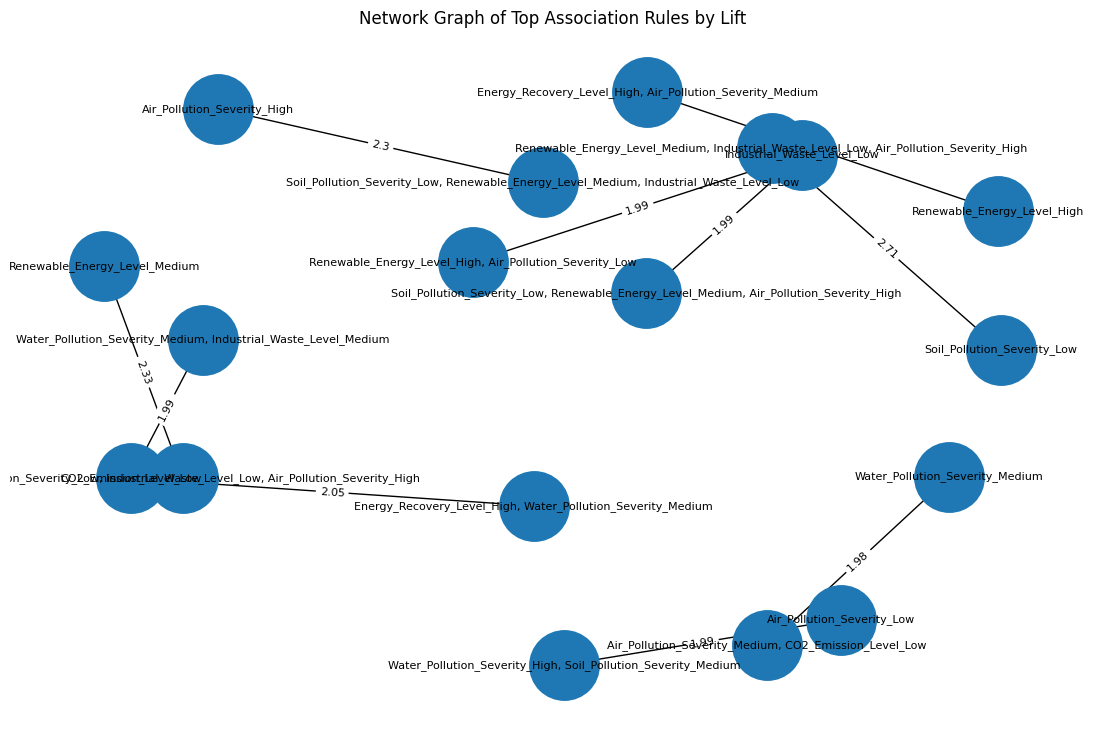

In [41]:
# 21. Network Graph of Top Rules by Lift
# ============================================================

top_rules_graph = strong_rules.sort_values(
    by='lift',
    ascending=False
).head(10)

G = nx.DiGraph()

for _, row in top_rules_graph.iterrows():

    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    lift = row['lift']

    G.add_edge(antecedent, consequent, weight=lift)

plt.figure(figsize=(14, 9))

pos = nx.spring_layout(G, k=1.2, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=2500
)

nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle='->',
    arrowsize=20
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

edge_labels = nx.get_edge_attributes(G, 'weight')
edge_labels = {key: round(value, 2) for key, value in edge_labels.items()}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title('Network Graph of Top Association Rules by Lift')
plt.axis('off')
plt.show()

In [42]:
# ============================================================
# 22. Country-Level Analysis
# ============================================================

possible_country_cols = ['Country_Name', 'Country', 'country', 'country_name']

country_col = None

for col in possible_country_cols:
    if col in df.columns:
        country_col = col
        break

print("Detected Country Column:", country_col)

if country_col is not None:

    country_rule_counts = {}

    for _, rule in strong_rules.iterrows():

        ants = list(rule['antecedents'])
        cons = list(rule['consequents'])

        all_items = ants + cons

        matching_rows = encoded_df[all_items].all(axis=1)

        matched_countries = df.loc[matching_rows, country_col]

        for country in matched_countries:
            country_rule_counts[country] = country_rule_counts.get(country, 0) + 1

    country_rule_df = pd.DataFrame(
        list(country_rule_counts.items()),
        columns=['Country', 'Strong_Rule_Appearances']
    )

    country_rule_df = country_rule_df.sort_values(
        by='Strong_Rule_Appearances',
        ascending=False
    ).reset_index(drop=True)

    print("Top countries appearing in strong rule patterns:")
    display(country_rule_df.head(10))

else:
    print("No country column found. Please check the dataset column names.")

Detected Country Column: Country
Top countries appearing in strong rule patterns:


,Country,Strong_Rule_Appearances
0,Solomon Islands,14
1,Spain,10
2,Estonia,9
3,Hong Kong,9
4,Holy See (Vatican City State),9
5,Afghanistan,9
6,Equatorial Guinea,8
7,Kenya,8
8,Angola,8
9,Tokelau,8


In [43]:
# ============================================================
# 23. Country-Specific Recommendations
# ============================================================

if country_col is not None and not country_rule_df.empty:

    top_5_countries = country_rule_df.head(5)

    print("Top 5 Countries:")
    display(top_5_countries)

    for country in top_5_countries['Country']:

        country_data = df[df[country_col] == country]

        print("=" * 80)
        print("Country:", country)
        print("=" * 80)

        country_profile = country_data[category_cols].mode().iloc[0]

        print(country_profile)

        print("\nRecommendations:")

        if country_profile['Air_Pollution_Severity'] == 'High':
            print("- Strengthen air pollution control through clean transport and emission standards.")

        if country_profile['Water_Pollution_Severity'] == 'High':
            print("- Improve wastewater treatment and control industrial discharge.")

        if country_profile['Soil_Pollution_Severity'] == 'High':
            print("- Reduce chemical contamination and improve soil protection policies.")

        if country_profile['Industrial_Waste_Level'] == 'High':
            print("- Improve industrial waste recycling and treatment systems.")

        if country_profile['CO2_Emission_Level'] == 'High':
            print("- Reduce fossil fuel use and improve energy efficiency.")

        if country_profile['Energy_Recovery_Level'] == 'Low':
            print("- Invest in waste-to-energy and industrial heat recovery systems.")

        if country_profile['Renewable_Energy_Level'] == 'Low':
            print("- Increase renewable energy adoption such as solar, wind, hydro, and biomass.")

        print()

Top 5 Countries:


,Country,Strong_Rule_Appearances
0,Solomon Islands,14
1,Spain,10
2,Estonia,9
3,Hong Kong,9
4,Holy See (Vatican City State),9


Country: Solomon Islands
Air_Pollution_Severity        High
Water_Pollution_Severity       Low
Soil_Pollution_Severity        Low
Industrial_Waste_Level         Low
CO2_Emission_Level          Medium
Energy_Consumption_Level    Medium
Energy_Recovery_Level       Medium
Renewable_Energy_Level      Medium
Name: 0, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

Recommendations:
- Strengthen air pollution control through clean transport and emission standards.

Country: Spain
Air_Pollution_Severity         Low
Water_Pollution_Severity    Medium
Soil_Pollution_Severity        Low
Industrial_Waste_Level         Low
CO2_Emission_Level             Low
Energy_Consumption_Level       Low
Energy_Recovery_Level          Low
Renewable_Energy_Level         Low
Name: 0, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

Recommendations:
- Invest in waste-to-energy and industrial heat recovery systems.
- Increase renewable energy adoption such as solar, wind, hydro, a

In [44]:
# ============================================================
# 24. Save Final Results
# ============================================================

frequent_itemsets.to_csv("frequent_itemsets.csv", index=False)
rules.to_csv("association_rules.csv", index=False)
strong_rules.to_csv("strong_significant_rules.csv", index=False)
chi2_df.to_csv("chi_square_results.csv", index=False)
sensitivity_df.to_csv("sensitivity_analysis.csv", index=False)

if country_col is not None and not country_rule_df.empty:
    country_rule_df.to_csv("country_rule_analysis.csv", index=False)

print("All output files saved successfully.")

All output files saved successfully.


In [45]:
# ============================================================
# 25. Final Summary
# ============================================================

print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

print("Dataset Size:", df.shape)
print("Minimum Support:", MIN_SUPPORT)
print("Minimum Confidence:", MIN_CONFIDENCE)
print("Total Frequent Itemsets:", len(frequent_itemsets))
print("Total Association Rules:", len(rules))
print("Strong Significant Rules:", len(strong_rules))

if len(rules) > 0:
    print("Average Support:", round(rules['support'].mean(), 4))
    print("Average Confidence:", round(rules['confidence'].mean(), 4))
    print("Average Lift:", round(rules['lift'].mean(), 4))
    print("Maximum Lift:", round(rules['lift'].max(), 4))

if not strong_rules.empty:
    best_rule = strong_rules.iloc[0]

    print("\nBest Rule by Lift:")
    print("Antecedents:", best_rule['antecedents'])
    print("Consequents:", best_rule['consequents'])
    print("Support:", round(best_rule['support'], 4))
    print("Confidence:", round(best_rule['confidence'], 4))
    print("Lift:", round(best_rule['lift'], 4))
    print("p-value:", round(best_rule['p_value'], 4))

FINAL SUMMARY
Dataset Size: (200, 21)
Minimum Support: 0.05
Minimum Confidence: 0.6
Total Frequent Itemsets: 566
Total Association Rules: 34
Strong Significant Rules: 34
Average Support: 0.0654
Average Confidence: 0.6453
Average Lift: 1.9355
Maximum Lift: 2.7137

Best Rule by Lift:
Antecedents: frozenset({'Renewable_Energy_Level_Medium', 'Industrial_Waste_Level_Low', 'Air_Pollution_Severity_High'})
Consequents: frozenset({'Soil_Pollution_Severity_Low'})
Support: 0.05
Confidence: 0.9091
Lift: 2.7137
p-value: 0.0001
